In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [4]:
x=6*np.random.rand(100,1)-3
# first 5 rows
y=0.5*x**2+ 1.5*x +2 +np.random.randn(100,1)


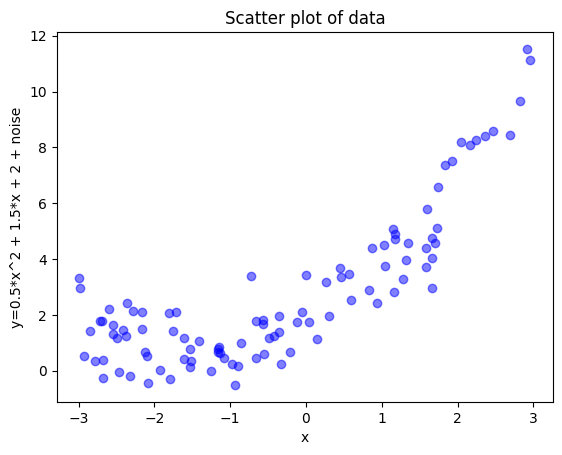

In [5]:
# plot the data
plt.scatter(x,y,color='blue', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y=0.5*x^2 + 1.5*x + 2 + noise')
plt.title('Scatter plot of data')
plt.show()
# here noise=outlier

### here we are going to use polynomial regression to fit a polynomial to the data

In [6]:
import sklearn

In [7]:
from sklearn.model_selection import train_test_split
# split the data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


### lets perform simple linear regression first

In [8]:
from sklearn.linear_model import LinearRegression
# create a linear regression model
model_1 = LinearRegression()
# fit the model to the training data
model_1.fit(x_train, y_train)


LinearRegression()

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
# make predictions on the test data
y_pred = model_1.predict(x_test)
# calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
r2= r2_score(y_test, y_pred)
print("R^2 Score:", r2)

Mean Squared Error: 1.869662896994198
R^2 Score: 0.36254845180344497


In [10]:
y_pred_train = model_1.predict(x_train)

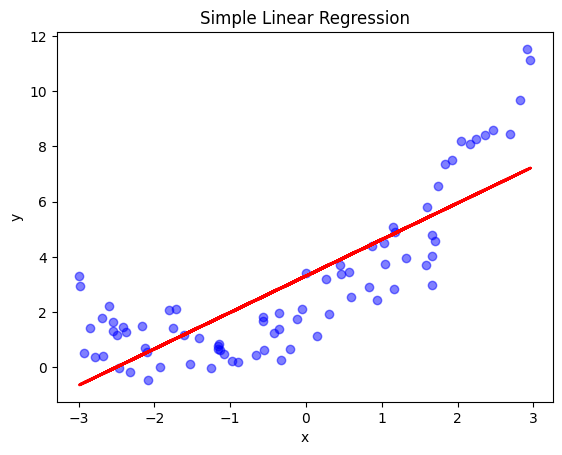

In [11]:
# plot the simple linear regression line
plt.scatter(x_train, y_train, color='blue', alpha=0.5)
plt.plot(x_train, y_pred_train, color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.show()

### lets apply polynomial transfromation

In [12]:
from sklearn.preprocessing import PolynomialFeatures

In [13]:
poly=PolynomialFeatures(degree=2, include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [14]:
x_train_poly[:5]

array([[ 1.        ,  1.16947787,  1.36767848],
       [ 1.        ,  0.59424438,  0.35312638],
       [ 1.        , -1.80109781,  3.24395331],
       [ 1.        ,  0.15159309,  0.02298047],
       [ 1.        , -0.89333011,  0.79803868]])

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model_2 = LinearRegression()
model_2.fit(x_train_poly, y_train)
y_pred_train_poly = model_2.predict(x_train_poly)
y_pred_test_poly = model_2.predict(x_test_poly)
# calculate the mean squared error
# mse_train_poly = mean_squared_error(y_train, y_pred_train_poly)
# print("Train Mean Squared Error:", mse_train_poly)
# mse_test_poly = mean_squared_error(y_test, y_pred_test_poly)
# print("Test Mean Squared Error:", mse_test_poly)
# r2_train_poly = r2_score(y_train, y_pred_train_poly)
# print("Train R^2 Score:", r2_train_poly)
r2_test_poly = r2_score(y_test, y_pred_test_poly)
print("Test R^2 Score:", r2_test_poly)

Test R^2 Score: 0.6524566960946028


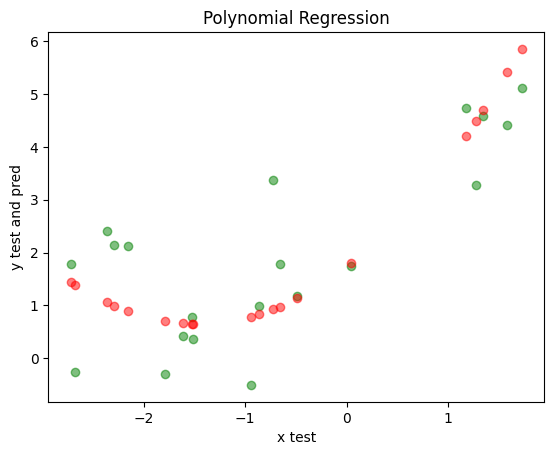

In [16]:
# plot the polynomial regression curve
# plt.scatter(x_train, y_train, color='blue', alpha=0.5)
plt.scatter(x_test, y_test, color='green', alpha=0.5)
plt.scatter(x_test, y_pred_test_poly, color='red', alpha=0.5)
plt.xlabel('x test')
plt.ylabel('y test and pred')
plt.title('Polynomial Regression')
plt.show()


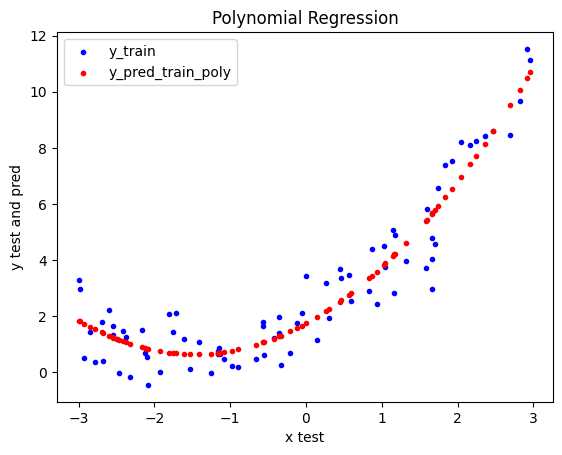

In [20]:
# plot the polynomial regression curve
plt.scatter(x_train, y_train, color='blue',marker='.')
plt.scatter(x_train, y_pred_train_poly, color='red', marker='.')
plt.xlabel('x test')
plt.ylabel('y test and pred')
plt.title('Polynomial Regression')
plt.legend(['y_train', 'y_pred_train_poly'])
plt.show()